# Imports

In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import re, string

from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

 # Load Dataset

In [104]:
df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\AI_Human_Detector_Project\ai_vs_human_text.csv")
print(df)




       id                                               text          label  \
0       1  AI-generated content sample 1: This is an exam...   AI-generated   
1       2  AI-generated content sample 2: This is an exam...   AI-generated   
2       3  Human-written text sample 3: This is an exampl...  Human-written   
3       4  AI-generated content sample 4: This is an exam...   AI-generated   
4       5  Human-written text sample 5: This is an exampl...  Human-written   
..    ...                                                ...            ...   
995   996  AI-generated content sample 996: This is an ex...   AI-generated   
996   997  Human-written text sample 997: This is an exam...  Human-written   
997   998  Human-written text sample 998: This is an exam...  Human-written   
998   999  Human-written text sample 999: This is an exam...  Human-written   
999  1000  AI-generated content sample 1000: This is an e...   AI-generated   

                                                pro

# Remove Duplicates

In [98]:
print("Duplicates Removed:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates Removed: 0


# Visualize Class Distribution

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8988\2806466880.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["label"], palette="viridis")


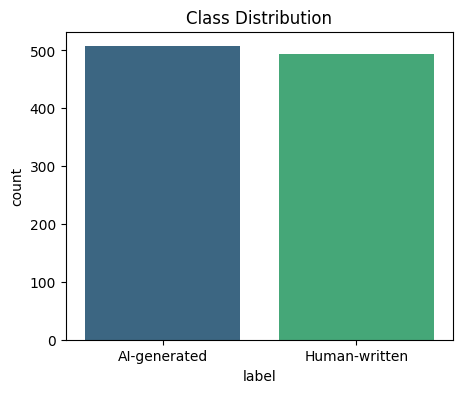

In [99]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["label"], palette="viridis")
plt.title("Class Distribution")
plt.show()

# NLP Cleaning Function

In [100]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'['+string.punctuation+']'," ", text)
    text = re.sub(r"\s+", " ", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)
df.head()

,id,text,label,prompt,model,date,clean_text
0,1,AI-generated content sample 1: This is an exam...,AI-generated,Explain the benefits of deep learning.,ChatGPT,2023-11-25,ai generated content sample 1 this is an examp...
1,2,AI-generated content sample 2: This is an exam...,AI-generated,Write an article on the future of AI.,Bard,2024-11-15,ai generated content sample 2 this is an examp...
2,3,Human-written text sample 3: This is an exampl...,Human-written,Editorial on the impact of technology in society.,Human,2024-08-11,human written text sample 3 this is an example...
3,4,AI-generated content sample 4: This is an exam...,AI-generated,Describe how neural networks work.,Claude,2024-04-27,ai generated content sample 4 this is an examp...
4,5,Human-written text sample 5: This is an exampl...,Human-written,Personal essay on learning programming.,Human,2024-08-15,human written text sample 5 this is an example...


# WordCloud for AI Text

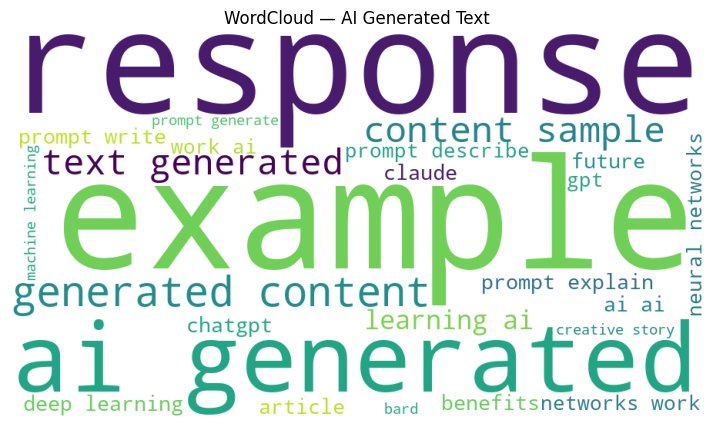

In [101]:
ai_text = " ".join(df[df.label=="AI-generated"]["clean_text"])
wc = WordCloud(width=900, height=500, background_color="white").generate(ai_text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud — AI Generated Text")
plt.show()

# WordCloud for Human Text

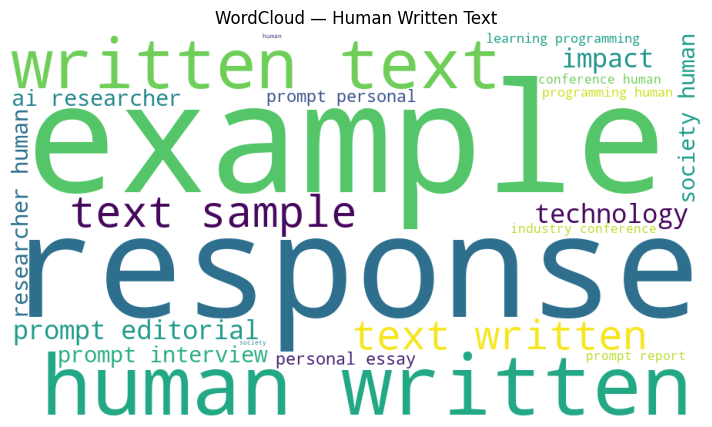

In [102]:
human_text = " ".join(df[df.label=="Human-written"]["clean_text"])
wc = WordCloud(width=900, height=500, background_color="white").generate(human_text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud — Human Written Text")
plt.show()

# TF-IDF Vectorization

In [89]:
vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1,2), min_df=3)
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Logistic Regression Training

In [90]:
lr = LogisticRegression(max_iter=3000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", acc_lr)
print(classification_report(y_test, pred_lr))

Logistic Regression Accuracy: 1.0
               precision    recall  f1-score   support

 AI-generated       1.00      1.00      1.00       127
Human-written       1.00      1.00      1.00       123

     accuracy                           1.00       250
    macro avg       1.00      1.00      1.00       250
 weighted avg       1.00      1.00      1.00       250



# Naive Bayes Training

In [ ]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, pred_nb)

print("Naive Bayes Accuracy:", acc_nb)
print(classification_report(y_test, pred_nb))

Naive Bayes Accuracy: 1.0
               precision    recall  f1-score   support

 AI-generated       1.00      1.00      1.00       127
Human-written       1.00      1.00      1.00       123

     accuracy                           1.00       250
    macro avg       1.00      1.00      1.00       250
 weighted avg       1.00      1.00      1.00       250



# prediction

In [ ]:
# ---------------------------------------------------------
# RULE-BASED FINAL DECISION
# ---------------------------------------------------------

def apply_confidence_rule(confidence):
    if confidence >= 80:
        return "✅ Acceptable (High certainty)"
    elif 60 <= confidence < 80:
        return "❓ Needs Review (Moderate certainty)"
    else:
        return "⚠️ Likely AI-generated / Uncertain"


# ---------------------------------------------------------
# FINAL PREDICTION OUTPUT FOR 3 TEST CASES
# ---------------------------------------------------------

def show_prediction(text):
    label, conf = predict_text(text)   # conf already in %
    decision = apply_confidence_rule(conf)

    print("📝 INPUT TEXT :", text)
    print("🔮 PREDICTION :", label)
    print("📊 CONFIDENCE :", conf, "%")
    print("📌 FINAL DECISION :", decision)
    print("-" * 70)


# ---------------------------------------------------------
# 3 EXAMPLE TEST CASES
# ---------------------------------------------------------

test1 = "Artificial intelligence is transforming how humans solve problems."
test2 = "I had a really fun day today and wanted to write it down."
test3 = "The algorithm follows a sequential process to generate the final result."

show_prediction(test1)
show_prediction(test2)
show_prediction(test3)

📝 INPUT TEXT : Artificial intelligence is transforming how humans solve problems.
🔮 PREDICTION : HUMAN-WRITTEN ✍️😊
📊 CONFIDENCE : 50.67 %
📌 FINAL DECISION : ⚠️ Likely AI-generated / Uncertain
----------------------------------------------------------------------
📝 INPUT TEXT : I had a really fun day today and wanted to write it down.
🔮 PREDICTION : HUMAN-WRITTEN ✍️😊
📊 CONFIDENCE : 96.19 %
📌 FINAL DECISION : ✅ Acceptable (High certainty)
----------------------------------------------------------------------
📝 INPUT TEXT : The algorithm follows a sequential process to generate the final result.
🔮 PREDICTION : HUMAN-WRITTEN ✍️😊
📊 CONFIDENCE : 95.71 %
📌 FINAL DECISION : ✅ Acceptable (High certainty)
----------------------------------------------------------------------


In [95]:
# =====================================
# AI vs Human Text Detector Training
# =====================================

import pandas as pd
import numpy as np
import re
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -------------------------------
# 1. Load CSV
# -------------------------------
df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\AI_Human_Detector_Project\ai_vs_human_text.csv")  # <-- Replace with your CSV path
# CSV must have columns: 'text' and 'label' (0=human, 1=AI)

print("Dataset shape:", df.shape)
print(df.head())

# -------------------------------
# 2. Clean Text Function
# -------------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\n',' ', text)  # remove newlines
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(clean_text)

# -------------------------------
# 3. Train/Test Split
# -------------------------------
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 4. Vectorize Text
# -------------------------------
vectorizer = TfidfVectorizer(
    ngram_range=(1,3),  # unigrams, bigrams, trigrams
    min_df=2,
    max_df=0.9,
    strip_accents='unicode'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# -------------------------------
# 5. Train Classifier
# -------------------------------
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train_vec, y_train)

# -------------------------------
# 6. Evaluate Model
# -------------------------------
y_pred = model.predict(X_test_vec)
y_proba = model.predict_proba(X_test_vec)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# -------------------------------
# 7. Save Model and Vectorizer
# -------------------------------
with open("../backend/model/model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("../backend/model/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("✅ Model and Vectorizer saved successfully!")

Dataset shape: (1000, 6)
   id                                               text          label  \
0   1  AI-generated content sample 1: This is an exam...   AI-generated   
1   2  AI-generated content sample 2: This is an exam...   AI-generated   
2   3  Human-written text sample 3: This is an exampl...  Human-written   
3   4  AI-generated content sample 4: This is an exam...   AI-generated   
4   5  Human-written text sample 5: This is an exampl...  Human-written   

                                              prompt    model        date  
0             Explain the benefits of deep learning.  ChatGPT  2023-11-25  
1              Write an article on the future of AI.     Bard  2024-11-15  
2  Editorial on the impact of technology in society.    Human  2024-08-11  
3                 Describe how neural networks work.   Claude  2024-04-27  
4            Personal essay on learning programming.    Human  2024-08-15  
Accuracy: 1.0

Classification Report:
                precision    r